In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


salary_income = pd.read_csv('../data/employee_income.csv')

salary_income.head()

,age,experience,income
0,50,5,45118
1,36,9,41691
2,29,3,35994
3,42,5,41614
4,40,12,51474


In [2]:
# Explore the data 
salary_income.info()
salary_income.describe()
salary_income.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         57 non-null     int64
 1   experience  57 non-null     int64
 2   income      57 non-null     int64
dtypes: int64(3)
memory usage: 1.5 KB


age           0
experience    0
income        0
dtype: int64

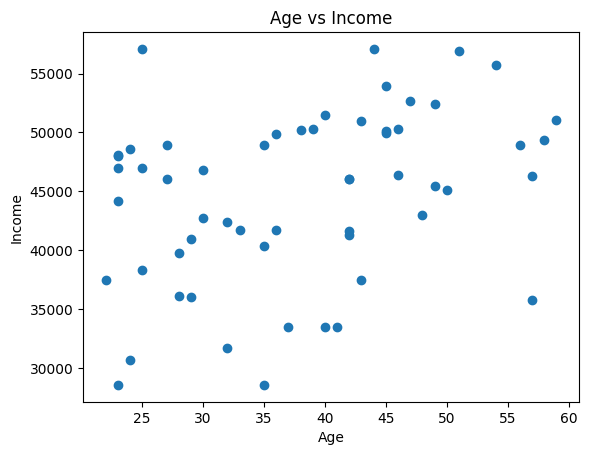

In [5]:
# A scatter plot of Age vs Income
plt.scatter(salary_income['age'], salary_income['income'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Age vs Income')
plt.show()

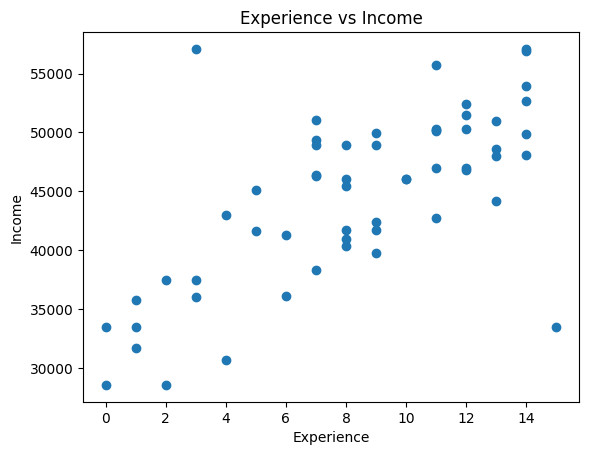

In [6]:
# Scatter plot of Experience vs Income
plt.scatter(salary_income['experience'], salary_income['income'])
plt.xlabel('Experience')
plt.ylabel('Income')        
plt.title('Experience vs Income')
plt.show()

In [7]:
# Define Features(Experience) and Target(Income)
X = salary_income['experience'].values.reshape(-1, 1)
y = salary_income['income'].values.reshape(-1, 1)


In [8]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Train the Linear Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train) 


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
# Make predictions
y_pred = model.predict(X_test)
print("Predicted values:", y_pred.flatten())
print("Actual values:", y_test.flatten())

Predicted values: [40939.32448708 51010.46837197 44296.37244871 49891.45238476
 48772.43639755 46534.40442313 39820.30849987 47653.42041034
 47653.42041034 38701.29251266 43177.3564615  40939.32448708]
Actual values: [45118 57092 46088 47998 50284 46015 30702 42706 50179 37504 38314 41614]


In [ ]:
# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score

mse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Mean error: {mse:3.3} ({mse/np.mean(y_test)*100:3.3}%)')
print("R-squared:", {r2:3.3} )

Mean error: 4.12e+03 (9.26%)
R-squared: {0.6169465713614972: 3.3}


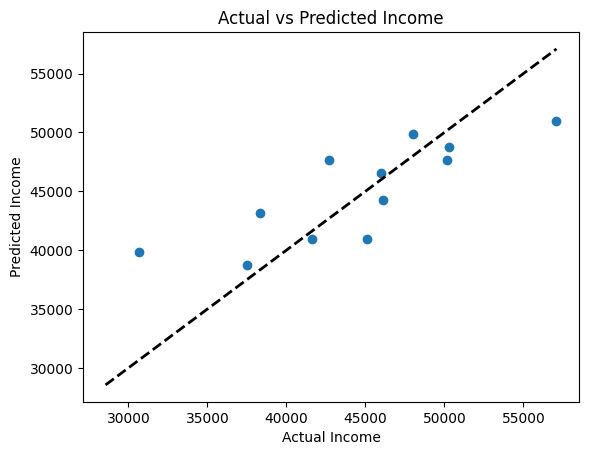

In [16]:
# Plot Predicted vs Actual values
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Income') 
plt.ylabel('Predicted Income')
plt.title('Actual vs Predicted Income')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # Line for perfect predictions
plt.show()

In [17]:
# Check the coefficients
print("Coefficient (slope):", model.coef_[0][0])
print("Intercept:", model.intercept_[0])


Coefficient (slope): 1119.0159872102317
Intercept: 35344.24455102585
